# Data Analysis for Emotion Classification

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [54]:
df = pd.read_csv('tracks_with_lyrics.csv', encoding='utf-8')

In [55]:
df.head()

,track_id,title,artist,genre,release_year,popularity,lyrics
0,2lKNANmq1EjeXcTyY01tGq,Bad Habits,Ed Sheeran,pop,2023,17,"(One, two, three, four)\nOoh, ooh\nEvery time ..."
1,1OIyqRCSCSsTpORSVcSbJH,Light Switch,Charlie Puth,pop,2023,13,Yeah\nWhy you callin' at 11:30\nWhen you only ...
2,7973tPp6ZA4q1AAEoLLMqE,Iris,The Goo Goo Dolls,pop,2023,11,And I'd give up forever to touch you\n'Cause I...
3,5fYNlXNcNp8BzgezT733jo,Overwhelmed,Royal & the Serpent,pop,2023,3,"To report suspicious activity, you can call 91..."
4,4xeRHrHTOij2Ux6aHRlq0O,Infinity,Jaymes Young,pop,2023,11,"(Oh, oh)\n(Oh, oh, oh)\n(Oh, oh)\n(Oh, oh, oh)..."


In [56]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7219 entries, 0 to 7218
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   track_id      7219 non-null   object
 1   title         7219 non-null   object
 2   artist        7219 non-null   object
 3   genre         7219 non-null   object
 4   release_year  7219 non-null   int64 
 5   popularity    7219 non-null   int64 
 6   lyrics        7219 non-null   object
dtypes: int64(2), object(5)
memory usage: 394.9+ KB


(7219, 7)

In [57]:
df.isnull().sum()
df = df.dropna(subset=['lyrics'])

In [58]:
for col in df.columns:
  print(col, df[col].nunique())
print(len(df))

track_id 7219
title 6296
artist 2694
genre 6
release_year 48
popularity 98
lyrics 6500
7219


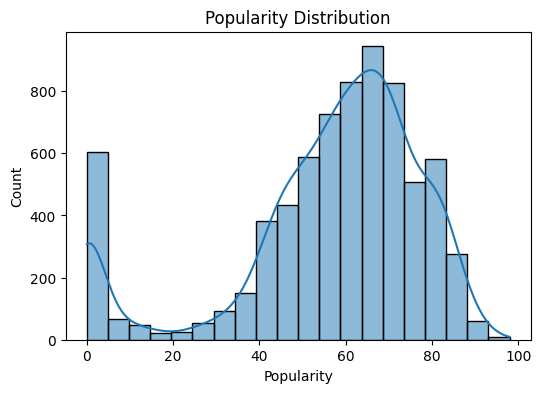

In [59]:
plt.figure(figsize=(6,4))
sns.histplot(df['popularity'], bins=20, kde=True)
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()


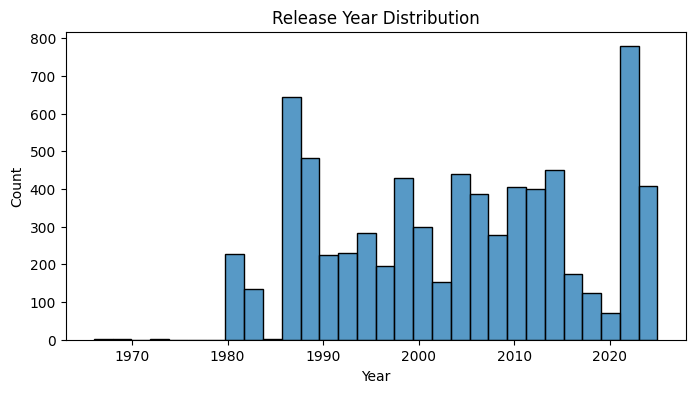

In [60]:
plt.figure(figsize=(8,4))
sns.histplot(df['release_year'], bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

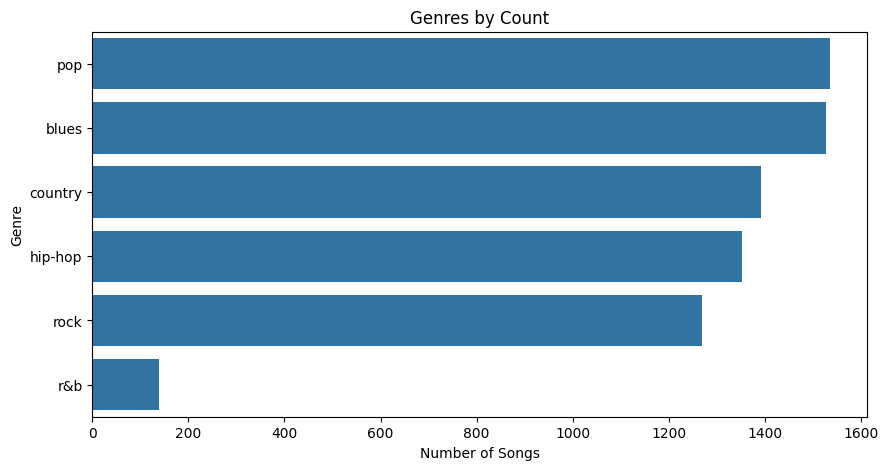

genre
pop        1537
blues      1528
country    1393
hip-hop    1353
rock       1269
r&b         139
Name: count, dtype: int64

In [61]:
plt.figure(figsize=(10,5))
top_genres = df['genre'].value_counts().nlargest(15)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Genres by Count")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.show()
df['genre'].value_counts()

In [62]:
df['char_count'] = df['lyrics'].str.len()
df['word_count'] = df['lyrics'].str.split().apply(len)


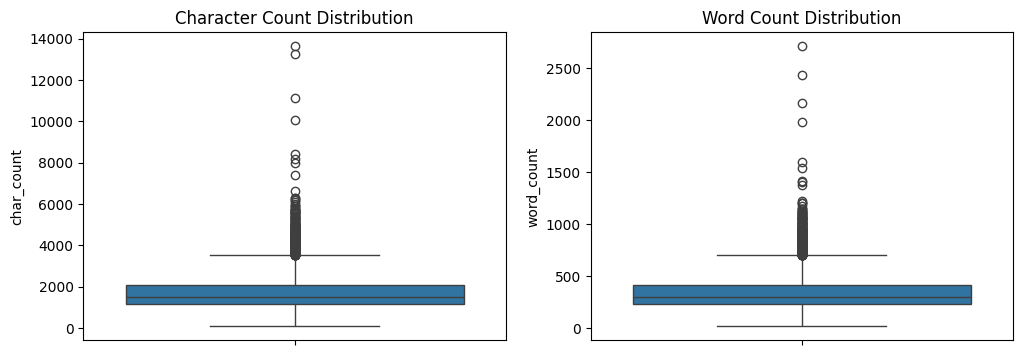

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=df['char_count'], ax=axes[0])
axes[0].set_title("Character Count Distribution")
sns.boxplot(y=df['word_count'], ax=axes[1])
axes[1].set_title("Word Count Distribution")
plt.show()

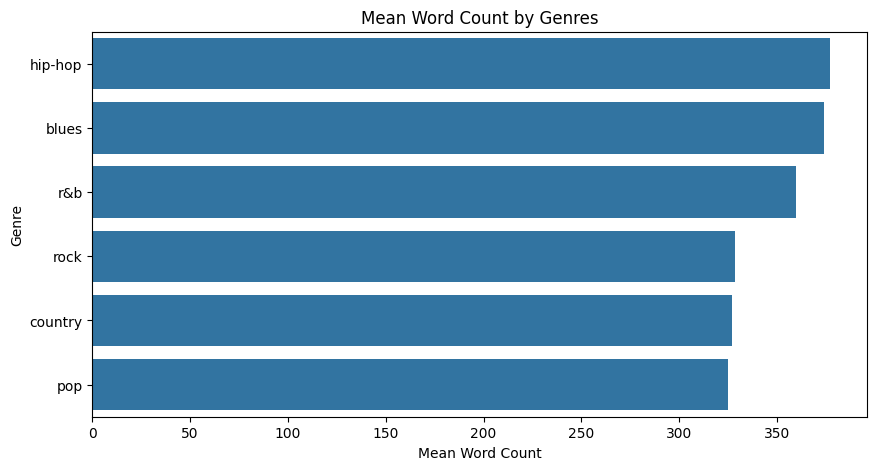

In [64]:
plt.figure(figsize=(10,5))
mean_words_by_genre = df.groupby('genre')['word_count'].mean().sort_values(ascending=False)
sns.barplot(x=mean_words_by_genre.values, y=mean_words_by_genre.index)
plt.title("Mean Word Count by Genres")
plt.xlabel("Mean Word Count")
plt.ylabel("Genre")
plt.show()

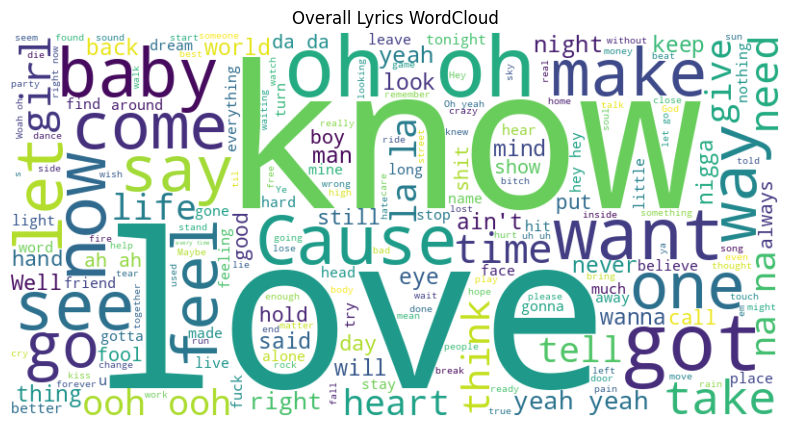

In [65]:
text_all = " ".join(df['lyrics'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Overall Lyrics WordCloud")
plt.show()
